### 1. Setup e Imports

In [1]:
import json as _json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from tqdm import tqdm
import os
import sys
from pathlib import Path

# Agregar path del proyecto para imports
sys.path.append(os.path.abspath('../../..'))
from sae.models.sae import SparseAutoencoder
from sae.tools.naming_utils import save_checkpoint, get_model_name, get_extras_id, get_checkpoint_dir
from sae.tools.experiment_utils import get_experiment_dir, get_plots_dir, get_metrics_dir, get_report_name

# Configuración de visualización para Quarto/PDF
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', None)
np.set_printoptions(linewidth=100, precision=4)
os.environ['COLUMNS'] = '100'

# Configuración de reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Print config con formato profesional
config_df = pd.DataFrame({
    'Configuración': ['Device', 'Seed', 'Output Width'],
    'Valor': [str(device), '42', '100']
})

print('\n' + '='*50)
print(' CONFIGURACIÓN INICIAL')
print('='*50)
print(config_df.to_string(index=False))
print('='*50)


 CONFIGURACIÓN INICIAL
Configuración Valor
       Device  cuda
         Seed    42
 Output Width   100


### 2 Metadata para Naming de Checkpoints

In [2]:
# Metadata para naming de checkpoints (separada de hiperparámetros)
NAMING_META = {
    'variante': 'standard',          # Arquitectura del SAE
    'tecnica': 'p-annealing',        # P-annealing (Lp^p con p decreciente)
    'capa': 6,                       # Layer del modelo OthelloGPT
    'juegos': 12500,                # Número de partidas
    'base_path': 'C:\\Users\\Esposa\\Documents\\Repos\\sae-othello-gpt',  # Path base para checkpoints
    'experiment_base_path': os.path.abspath('../../../experiments') ,      # sae/experiments/
    'extras': {          
        'expansion': 16,
        'sparsity_coef': 3e-1,
        'epochs': 200,
        'early_stopping': False,
        'learning_rate': 1e-3,
        'p_start': 1.0,
        'p_end': 0.2,
        'n_sparsity_updates': 11,
        'anneal_start': 5000,
        'batch_size': 2048,
        'warmup_steps': 1000,
        'sparsity_warmup_steps': 2000,
        'estimated_epochs': 200
    }
}

print('\n Metadata de naming:')
for key, value in NAMING_META.items():
    print(f'  {key}: {value}')


 Metadata de naming:
  variante: standard
  tecnica: p-annealing
  capa: 6
  juegos: 12500
  base_path: C:\Users\Esposa\Documents\Repos\sae-othello-gpt
  experiment_base_path: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments
  extras: {'expansion': 16, 'sparsity_coef': 0.3, 'epochs': 200, 'early_stopping': False, 'learning_rate': 0.001, 'p_start': 1.0, 'p_end': 0.2, 'n_sparsity_updates': 11, 'anneal_start': 5000, 'batch_size': 2048, 'warmup_steps': 1000, 'sparsity_warmup_steps': 2000, 'estimated_epochs': 200}


In [3]:
extras_id = get_extras_id(
    get_checkpoint_dir(
        NAMING_META['base_path'],
        NAMING_META['variante'],
        NAMING_META['tecnica'],
        NAMING_META['capa'],
        NAMING_META['juegos']
    ),
    NAMING_META['extras']
) if NAMING_META.get('extras') else None

print(f'extras_id: {extras_id}')

✓ Nuevo extras registrado: ex4 → {'expansion': 16, 'sparsity_coef': 0.3, 'epochs': 200, 'early_stopping': False, 'learning_rate': 0.001, 'p_start': 1.0, 'p_end': 0.2, 'n_sparsity_updates': 11, 'anneal_start': 5000, 'batch_size': 2048, 'warmup_steps': 1000, 'sparsity_warmup_steps': 2000, 'estimated_epochs': 200}
extras_id: ex4


### 3. Configuración del SAE

Las activaciones ya fueron extraídas previamente con `sae/activations/run_extraction.py`.  
Aquí especificamos qué archivo cargar y los hiperparámetros del SAE.

In [4]:
# Configuración del SAE
CONFIG = {
    # Arquitectura
    'input_dim': 512,
    'hidden_dim': 8192,
    'tied_weights': False,
    
    # Entrenamiento
    'batch_size': 2048,
    'num_epochs': 200,
    'learning_rate': 1e-3,
    'warmup_steps': 1000,        # steps de LR warmup lineal
    'sparsity_warmup_steps': 2000, # steps de rampa de sparsity (0→1)
    'sparsity_coef': 3e-1,       # alpha inicial (loss sum(dim=-1).mean())
    
    # P-annealing
    'p_start': 1.0,              # p inicial (equivalente a L1)
    'p_end': 0.2,                # p final
    'n_sparsity_updates': 11,    # número de saltos discretos
    'anneal_start': 5000,        # step en que empieza el annealing (después del warmup)
    'estimated_epochs': 200,       # épocas estimadas para condensar el schedule
    
    # Early Stopping
    'early_stopping': False,
    'patience': 50,                # (inactivo: early_stopping=False)
    
    # Datos
    'activations_file': Path(f"../../../activations/data/layer{NAMING_META['capa']}_{NAMING_META['juegos']}games.npy"),
    'save_dir': Path('./saved_model'),
    'plots_dir': get_plots_dir(
        NAMING_META['experiment_base_path'],
        NAMING_META['variante'],
        NAMING_META['tecnica'],
        NAMING_META['capa'],
        NAMING_META['juegos'],
        extras_id=extras_id
    )
}

# Crear directorio local del modelo
CONFIG['save_dir'].mkdir(parents=True, exist_ok=True)

# Mostrar configuración
config_data = {
    'Categoría': [],
    'Parámetro': [],
    'Valor': []
}

for key in ['input_dim', 'hidden_dim', 'tied_weights']:
    config_data['Categoría'].append('Arquitectura')
    config_data['Parámetro'].append(key)
    config_data['Valor'].append(str(CONFIG[key]))

for key in ['batch_size', 'num_epochs', 'learning_rate', 'warmup_steps', 'sparsity_warmup_steps', 'sparsity_coef']:
    config_data['Categoría'].append('Entrenamiento')
    config_data['Parámetro'].append(key)
    config_data['Valor'].append(str(CONFIG[key]))

for key in ['p_start', 'p_end', 'n_sparsity_updates', 'anneal_start', 'estimated_epochs']:
    config_data['Categoría'].append('P-Annealing')
    config_data['Parámetro'].append(key)
    config_data['Valor'].append(str(CONFIG[key]))

for key in ['early_stopping', 'patience']:
    config_data['Categoría'].append('Early Stopping')
    config_data['Parámetro'].append(key)
    config_data['Valor'].append(str(CONFIG[key]))

config_table = pd.DataFrame(config_data)

print('\n' + '='*70)
print(' CONFIGURACIÓN DEL SAE')
print('='*70)
print(config_table.to_string(index=False))
print('='*70)

print(f'\nArchivo de activaciones: {CONFIG["activations_file"]}')
print(f'Expansión: {CONFIG["hidden_dim"]/CONFIG["input_dim"]:.1f}x')
print(f'Plots dir: {CONFIG["plots_dir"]}')
print('='*70)


 CONFIGURACIÓN DEL SAE
     Categoría             Parámetro Valor
  Arquitectura             input_dim   512
  Arquitectura            hidden_dim  8192
  Arquitectura          tied_weights False
 Entrenamiento            batch_size  2048
 Entrenamiento            num_epochs   200
 Entrenamiento         learning_rate 0.001
 Entrenamiento          warmup_steps  1000
 Entrenamiento sparsity_warmup_steps  2000
 Entrenamiento         sparsity_coef   0.3
   P-Annealing               p_start   1.0
   P-Annealing                 p_end   0.2
   P-Annealing    n_sparsity_updates    11
   P-Annealing          anneal_start  5000
   P-Annealing      estimated_epochs   200
Early Stopping        early_stopping False
Early Stopping              patience    50

Archivo de activaciones: ..\..\..\activations\data\layer6_12500games.npy
Expansión: 16.0x
Plots dir: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_p-annealing_standard\12500games\ex4\plots


### 4. Dataset de Activaciones (Train/Validation Split 80-20%)

In [5]:
class ActivationsDataset(Dataset):
    """Dataset para cargar activaciones extraídas"""
    
    def __init__(self, activations_path):
        self.activations = np.load(activations_path)
    
    def __len__(self):
        return len(self.activations)
    
    def __getitem__(self, idx):
        return torch.tensor(self.activations[idx], dtype=torch.float32)

# Cargar dataset completo
full_dataset = ActivationsDataset(CONFIG['activations_file'])

# Información del dataset con formato profesional
dataset_info = pd.DataFrame({
    'Propiedad': ['Total muestras', 'Shape', 'Dtype', 'Tamaño en memoria'],
    'Valor': [
        f"{len(full_dataset):,}",
        str(full_dataset.activations.shape),
        str(full_dataset.activations.dtype),
        f"{full_dataset.activations.nbytes / 1024**2:.2f} MB"
    ]
})
print('\n' + '='*50)
print(' DATASET DE ACTIVACIONES')
print('='*50)
print(dataset_info.to_string(index=False))
print('='*50)

# Split train/validation (80-20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Resumen del split con formato profesional
split_info = pd.DataFrame({
    'Conjunto': ['Train', 'Validation', 'Total'],
    'Muestras': [
        f"{len(train_dataset):,}",
        f"{len(val_dataset):,}",
        f"{len(full_dataset):,}"
    ],
    'Porcentaje': [
        f"{len(train_dataset)/len(full_dataset):.1%}",
        f"{len(val_dataset)/len(full_dataset):.1%}",
        "100.0%"
    ]
})
print('\n' + '='*50)
print(' SPLIT DE DATOS (80-20)')
print('='*50)
print(split_info.to_string(index=False))
print('='*50)

# Crear DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,  # No shuffle para validación
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

# Resumen de DataLoaders
loader_info = pd.DataFrame({
    'DataLoader': ['Train', 'Validation'],
    'Batches': [len(train_loader), len(val_loader)],
    'Batch Size': [CONFIG['batch_size'], CONFIG['batch_size']],
    'Shuffle': ['Sí', 'No']
})

print('\n' + '='*50)
print(' DATALOADERS')
print('='*50)
print(loader_info.to_string(index=False))
print('='*50)


 DATASET DE ACTIVACIONES
        Propiedad         Valor
   Total muestras       737,500
            Shape (737500, 512)
            Dtype       float32
Tamaño en memoria    1440.43 MB

 SPLIT DE DATOS (80-20)
  Conjunto Muestras Porcentaje
     Train  590,000      80.0%
Validation  147,500      20.0%
     Total  737,500     100.0%

 DATALOADERS
DataLoader  Batches  Batch Size Shuffle
     Train      289        2048      Sí
Validation       73        2048      No


### 5. Modelo: Sparse Autoencoder

Modelo importado desde `sae.models.sae.SparseAutoencoder`

**Arquitectura:**

- **Encoder**: Linear → ReLU (sparsity natural)- **Decoder**: Linear (reconstrucción)

In [6]:
# Crear modelo desde el módulo
model = SparseAutoencoder(
    input_dim=CONFIG['input_dim'],
    hidden_dim=CONFIG['hidden_dim'],
    tied_weights=CONFIG['tied_weights']
).to(device)

# Calcular parámetros
num_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
if CONFIG['tied_weights']:
    decoder_params = CONFIG['input_dim']  # Solo bias
else:
    decoder_params = sum(p.numel() for p in model.decoder.parameters())

# Resumen del modelo con formato profesional
model_info = pd.DataFrame({
    'Componente': ['Input', 'Encoder', 'Hidden (Latent)', 'Decoder', 'Output', 'Total'],
    'Dimensión': [
        CONFIG['input_dim'],
        f"{CONFIG['input_dim']} → {CONFIG['hidden_dim']}",
        CONFIG['hidden_dim'],
        f"{CONFIG['hidden_dim']} → {CONFIG['input_dim']}",
        CONFIG['input_dim'],
        '-'
    ],
    'Parámetros': [
        '-',
        f"{encoder_params:,}",
        '-',
        f"{decoder_params:,}",
        '-',
        f"{num_params:,}"
    ]
})

print('\n' + '='*70)
print(' ARQUITECTURA DEL MODELO')
print('='*70)
print(model_info.to_string(index=False))
print('='*70)
print(f'\n Factor de expansión: {CONFIG["hidden_dim"]/CONFIG["input_dim"]:.1f}x')
print(f' Tied weights: {"Sí" if CONFIG["tied_weights"] else "No"}')
print(f' Device: {device}')
print('='*70)


 ARQUITECTURA DEL MODELO
     Componente  Dimensión Parámetros
          Input        512          -
        Encoder 512 → 8192  4,202,496
Hidden (Latent)       8192          -
        Decoder 8192 → 512  4,194,304
         Output        512          -
          Total          -  8,397,312

 Factor de expansión: 16.0x
 Tied weights: No
 Device: cuda


### 6. Función de Pérdida

**Loss = MSE(reconstrucción) + λ × L1(activaciones)**

- **MSE**: Mide qué tan bien reconstruimos las activaciones originales
- **L1**: Penaliza activaciones grandes → fuerza sparsity

In [7]:
class ConstrainedAdam(torch.optim.Adam):
    """
    Adam donde las columnas de decoder se proyectan a norma unitaria en cada step.
    Antes del paso: elimina la componente del gradiente paralela al decoder.
    Después del paso: renormaliza las columnas del decoder a norma 1.
    """
    def __init__(self, params, constrained_params, lr, betas=(0.9, 0.999)):
        super().__init__(params, lr=lr, betas=betas)
        self.constrained_params = list(constrained_params)

    def step(self, closure=None):
        with torch.no_grad():
            for p in self.constrained_params:
                normed_p = p / p.norm(dim=0, keepdim=True)
                p.grad -= (p.grad * normed_p).sum(dim=0, keepdim=True) * normed_p
        super().step(closure=closure)
        with torch.no_grad():
            for p in self.constrained_params:
                p /= p.norm(dim=0, keepdim=True)


def loss_function(x, reconstruction, hidden, sparsity_coeff, p, step=0, sparsity_warmup_steps=0):
    """
    Pérdida compuesta: MSE (sum/mean) + Lp^p penalty con sparsity warmup

    Args:
        x: Activaciones originales
        reconstruction: Activaciones reconstruidas
        hidden: Activaciones latentes (sparse, >= 0 por ReLU)
        sparsity_coeff: Peso adaptativo de la penalización (alpha)
        p: Exponente actual del schedule de annealing
        step: Step global actual (para sparsity warmup)
        sparsity_warmup_steps: Steps de rampa de sparsity (0 = desactivado)
    """
    # BUG2 FIX: sum sobre features luego mean sobre batch (igual que referencia)
    mse_loss = (reconstruction - x).pow(2).sum(dim=-1).mean()
    # BUG4 FIX: sparsity warmup — rampa lineal de 0 a 1
    sparsity_scale = min(step / sparsity_warmup_steps, 1.0) if sparsity_warmup_steps > 0 else 1.0
    sparsity_loss = hidden.pow(p).sum(dim=1).mean()   # Lp^p: Σ|f_i|^p
    total_loss = mse_loss + sparsity_coeff * sparsity_scale * sparsity_loss
    return total_loss, mse_loss, sparsity_loss


# ConstrainedAdam: pasa model.decoder.parameters() como parámetros constrained
optimizer = ConstrainedAdam(
    model.parameters(),
    model.decoder.parameters(),
    lr=CONFIG['learning_rate']
)

# BUG3 FIX: LR warmup lineal — sube de 0 a lr en warmup_steps
def _lr_lambda(step):
    warmup = CONFIG.get('warmup_steps', 1000)
    return min(step / warmup, 1.0) if warmup > 0 else 1.0

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=_lr_lambda)

optim_info = pd.DataFrame({
    'Parámetro': ['Optimizador', 'Learning Rate', 'Sparsity Coef (inicial)', 'p_start', 'p_end', 'n_sparsity_updates', 'anneal_start'],
    'Valor': [
        'ConstrainedAdam',
        f"{CONFIG['learning_rate']:.0e}",
        f"{CONFIG['sparsity_coef']:.0e}",
        f"{CONFIG['p_start']}",
        f"{CONFIG['p_end']}",
        f"{CONFIG['n_sparsity_updates']}",
        f"{CONFIG['anneal_start']}"
    ]
})

print('\n' + '='*55)
print(' OPTIMIZACIÓN')
print('='*55)
print(optim_info.to_string(index=False))
print('='*55)


 OPTIMIZACIÓN
              Parámetro           Valor
            Optimizador ConstrainedAdam
          Learning Rate           1e-03
Sparsity Coef (inicial)           3e-01
                p_start             1.0
                  p_end             0.2
     n_sparsity_updates              11
           anneal_start            5000


### 7. Loop de Entrenamiento

In [8]:
# Historial de entrenamiento
history = {
    'train_total_loss': [],
    'train_mse_loss': [],
    'train_sparsity_loss': [],
    'train_l0_sparsity': [],
    'train_fraction_active': [],
    'val_total_loss': [],
    'val_mse_loss': [],
    'val_sparsity_loss': [],
    'val_l0_sparsity': [],
    'val_fraction_active': [],
    'sparsity_coef_history': [],   # snapshot de sparsity_coeff al final de cada época
    'p_history': [],               # snapshot de p al final de cada época
}

# Early stopping variables
best_val_mse = float('inf')
best_epoch = 0
epochs_no_improve = 0

# ========== P-ANNEALING STATE ==========
p = CONFIG['p_start']
next_p = None
p_step_count = 0
sparsity_coeff = CONFIG['sparsity_coef']
sparsity_queue = []
sparsity_queue_length = 10

total_steps = CONFIG['num_epochs'] * len(train_loader)
# BUG5 FIX: usar expected_steps (no total_steps) para que el schedule
# de annealing complete antes del early stopping
estimated_epochs = CONFIG.get('estimated_epochs', 50)
expected_steps = estimated_epochs * len(train_loader)
_update_steps_tensor = torch.linspace(
    CONFIG['anneal_start'], expected_steps, CONFIG['n_sparsity_updates'], dtype=torch.int
)
sparsity_update_steps_set = set(_update_steps_tensor.tolist())
sparsity_update_steps_list = sorted(sparsity_update_steps_set)
p_values = torch.linspace(CONFIG['p_start'], CONFIG['p_end'], CONFIG['n_sparsity_updates']).tolist()
global_step = 0

print(f'\n Iniciando entrenamiento: {CONFIG["num_epochs"]} épocas máximo')
print(f' P-annealing: p {CONFIG["p_start"]} → {CONFIG["p_end"]} en {CONFIG["n_sparsity_updates"]} saltos')
print(f'⏸  Early stopping: patience={CONFIG["patience"]} épocas')
print('=' * 70)

for epoch in range(CONFIG['num_epochs']):

    # ========== ENTRENAMIENTO ==========
    model.train()

    epoch_total_loss = 0
    epoch_mse_loss = 0
    epoch_sparsity_loss = 0
    epoch_l0 = 0
    epoch_fraction_active = 0

    pbar = tqdm(train_loader, desc=f'Época {epoch+1}/{CONFIG["num_epochs"]} [Train] p={p:.3f} α={sparsity_coeff:.2e}')

    for batch in pbar:
        x = batch.to(device)

        # Forward pass
        reconstruction, hidden = model(x)

        # ---- P-ANNEALING: lookahead para la cola ----
        with torch.no_grad():
            if next_p is not None:
                lp_curr = hidden.pow(p).sum(dim=1).mean().item()
                lp_next = hidden.pow(next_p).sum(dim=1).mean().item()
                sparsity_queue.append([lp_curr, lp_next])
                sparsity_queue = sparsity_queue[-sparsity_queue_length:]

            # Verificar si este step es un punto de actualización de p
            if (global_step in sparsity_update_steps_set
                    and p_step_count < CONFIG['n_sparsity_updates']
                    and global_step >= sparsity_update_steps_list[p_step_count]):
                # Re-escalar sparsity_coeff para compensar el cambio de magnitud de Lp^p
                if next_p is not None and len(sparsity_queue) > 0:
                    local_curr = sum(i[0] for i in sparsity_queue) / len(sparsity_queue)
                    local_next = sum(i[1] for i in sparsity_queue) / len(sparsity_queue)
                    if local_next > 0:
                        sparsity_coeff = sparsity_coeff * (local_curr / local_next)
                # Actualizar p al siguiente valor del schedule
                p = p_values[p_step_count]
                if p_step_count < CONFIG['n_sparsity_updates'] - 1:
                    next_p = p_values[p_step_count + 1]
                else:
                    next_p = CONFIG['p_end']
                p_step_count += 1

        # Calcular pérdida con p actual
        total_loss, mse_loss, sparsity_loss = loss_function(
            x, reconstruction, hidden, sparsity_coeff, p,
            step=global_step,
            sparsity_warmup_steps=CONFIG.get('sparsity_warmup_steps', 0)
        )

        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        scheduler.step()  # BUG3 FIX: LR warmup step

        global_step += 1

        # Métricas
        with torch.no_grad():
            l0 = (hidden > 0).float().sum(dim=1).mean().item()
            fraction_active = (hidden > 0).float().mean().item()

        epoch_total_loss += total_loss.item()
        epoch_mse_loss += mse_loss.item()
        epoch_sparsity_loss += sparsity_loss.item()
        epoch_l0 += l0
        epoch_fraction_active += fraction_active

        pbar.set_postfix({
            'loss': f'{total_loss.item():.4f}',
            'mse': f'{mse_loss.item():.4f}',
            'l0': f'{l0:.1f}',
            'p': f'{p:.3f}'
        })

    # Promedios de entrenamiento
    num_train_batches = len(train_loader)
    avg_train_total_loss = epoch_total_loss / num_train_batches
    avg_train_mse_loss = epoch_mse_loss / num_train_batches
    avg_train_sparsity_loss = epoch_sparsity_loss / num_train_batches
    avg_train_l0 = epoch_l0 / num_train_batches
    avg_train_fraction_active = epoch_fraction_active / num_train_batches

    # ========== VALIDACIÓN ==========
    model.eval()

    val_total_loss = 0
    val_mse_loss = 0
    val_sparsity_loss = 0
    val_l0 = 0
    val_fraction_active = 0

    with torch.no_grad():
        for batch in val_loader:
            x = batch.to(device)
            reconstruction, hidden = model(x)
            total_loss, mse_loss, sparsity_loss = loss_function(
                x, reconstruction, hidden, sparsity_coeff, p,
                step=global_step,
                sparsity_warmup_steps=CONFIG.get('sparsity_warmup_steps', 0)
            )
            l0 = (hidden > 0).float().sum(dim=1).mean().item()
            fraction_active = (hidden > 0).float().mean().item()

            val_total_loss += total_loss.item()
            val_mse_loss += mse_loss.item()
            val_sparsity_loss += sparsity_loss.item()
            val_l0 += l0
            val_fraction_active += fraction_active

    num_val_batches = len(val_loader)
    avg_val_total_loss = val_total_loss / num_val_batches
    avg_val_mse_loss = val_mse_loss / num_val_batches
    avg_val_sparsity_loss = val_sparsity_loss / num_val_batches
    avg_val_l0 = val_l0 / num_val_batches
    avg_val_fraction_active = val_fraction_active / num_val_batches

    # Guardar en historial
    history['train_total_loss'].append(avg_train_total_loss)
    history['train_mse_loss'].append(avg_train_mse_loss)
    history['train_sparsity_loss'].append(avg_train_sparsity_loss)
    history['train_l0_sparsity'].append(avg_train_l0)
    history['train_fraction_active'].append(avg_train_fraction_active)

    history['val_total_loss'].append(avg_val_total_loss)
    history['val_mse_loss'].append(avg_val_mse_loss)
    history['val_sparsity_loss'].append(avg_val_sparsity_loss)
    history['val_l0_sparsity'].append(avg_val_l0)
    history['val_fraction_active'].append(avg_val_fraction_active)

    history['sparsity_coef_history'].append(sparsity_coeff)
    history['p_history'].append(p)

    # ========== EARLY STOPPING ==========
    if CONFIG['early_stopping']:
        if avg_val_mse_loss < best_val_mse:
            best_val_mse = avg_val_mse_loss
            best_epoch = epoch + 1
            epochs_no_improve = 0

            best_checkpoint = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'config': CONFIG,
                'history': history,
                'epoch': best_epoch,
                'val_mse': best_val_mse
            }

            best_model_name = get_model_name(
                variante=NAMING_META['variante'],
                tecnica=NAMING_META['tecnica'],
                capa=NAMING_META['capa'],
                juegos=NAMING_META['juegos'],
                estado='best'
            )
            torch.save(best_checkpoint, CONFIG['save_dir'] / best_model_name)

            save_checkpoint(
                model,
                base_path=NAMING_META['base_path'],
                variante=NAMING_META['variante'],
                tecnica=NAMING_META['tecnica'],
                capa=NAMING_META['capa'],
                juegos=NAMING_META['juegos'],
                estado='best',
                extras=NAMING_META['extras'],
                config=CONFIG,
                history=history,
                optimizer=optimizer
            )

            print(f' Mejor modelo guardado en época {best_epoch} (Val MSE: {best_val_mse:.4f})')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= CONFIG['patience']:
                print(f'\n⏸  Early stopping activado en época {epoch+1}')
                print(f'   Mejor modelo: época {best_epoch} con Val MSE = {best_val_mse:.4f}')
                break

    # Log cada 5 épocas
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'\n Época {epoch+1}/{CONFIG["num_epochs"]} | p: {p:.3f} | α: {sparsity_coeff:.2e}')
        print(f'  Train - Total: {avg_train_total_loss:.4f} | MSE: {avg_train_mse_loss:.4f} | L0: {avg_train_l0:.1f}')
        print(f'  Val   - Total: {avg_val_total_loss:.4f} | MSE: {avg_val_mse_loss:.4f} | L0: {avg_val_l0:.1f}')
        if CONFIG['early_stopping']:
            print(f'   Best Val MSE: {best_val_mse:.4f} @ época {best_epoch} | Sin mejora: {epochs_no_improve}/{CONFIG["patience"]}')

print('\n' + '='*70)
print(' RESUMEN DEL ENTRENAMIENTO')
print('='*70)

if CONFIG['early_stopping']:
    print(f'Mejor modelo en época {best_epoch} con Val MSE = {best_val_mse:.4f}')
    print(f'Early stopping tras {len(history["train_total_loss"])} épocas')
else:
    print(f'Entrenamiento completo: {CONFIG["num_epochs"]} épocas')

final_metrics = pd.DataFrame({
    'Métrica': ['Total Loss', 'MSE Loss', 'L0 Sparsity', 'Fraction Active'],
    'Train': [
        f"{history['train_total_loss'][-1]:.4f}",
        f"{history['train_mse_loss'][-1]:.4f}",
        f"{history['train_l0_sparsity'][-1]:.1f}",
        f"{history['train_fraction_active'][-1]:.2%}"
    ],
    'Validation': [
        f"{history['val_total_loss'][-1]:.4f}",
        f"{history['val_mse_loss'][-1]:.4f}",
        f"{history['val_l0_sparsity'][-1]:.1f}",
        f"{history['val_fraction_active'][-1]:.2%}"
    ]
})

print('\nMétricas Finales (Última Época):')
print(final_metrics.to_string(index=False))
print('='*70)


 Iniciando entrenamiento: 200 épocas máximo
 P-annealing: p 1.0 → 0.2 en 11 saltos
⏸  Early stopping: patience=50 épocas


Época 1/200 [Train] p=1.000 α=3.00e-01: 100%|██████████| 289/289 [00:13<00:00, 21.83it/s, loss=19.5757, mse=4.4509, l0=4666.7, p=1.000] 



 Época 1/200 | p: 1.000 | α: 3.00e-01
  Train - Total: 18.5541 | MSE: 10.1224 | L0: 4846.5
  Val   - Total: 19.7317 | MSE: 4.4647 | L0: 4627.0


Época 5/200 [Train] p=1.000 α=3.00e-01: 100%|██████████| 289/289 [00:12<00:00, 23.67it/s, loss=50.4396, mse=14.2428, l0=1600.4, p=1.000]



 Época 5/200 | p: 1.000 | α: 3.00e-01
  Train - Total: 46.6758 | MSE: 12.5411 | L0: 1727.7
  Val   - Total: 50.2713 | MSE: 13.7496 | L0: 1589.5


...


 Época 190/200 | p: 0.280 | α: 1.53e-01
  Train - Total: 59.2647 | MSE: 25.2679 | L0: 286.3
  Val   - Total: 61.5591 | MSE: 27.6192 | L0: 286.2


Época 195/200 [Train] p=0.280 α=1.53e-01: 100%|██████████| 289/289 [00:10<00:00, 27.33it/s, loss=58.9126, mse=25.3624, l0=280.5, p=0.280]



 Época 195/200 | p: 0.280 | α: 1.53e-01
  Train - Total: 59.3246 | MSE: 25.2501 | L0: 285.8
  Val   - Total: 61.5384 | MSE: 27.5123 | L0: 285.5


Época 200/200 [Train] p=0.280 α=1.53e-01: 100%|██████████| 289/289 [00:10<00:00, 27.49it/s, loss=60.7720, mse=25.7986, l0=293.6, p=0.280]



 Época 200/200 | p: 0.280 | α: 1.53e-01
  Train - Total: 58.8964 | MSE: 24.6830 | L0: 286.6
  Val   - Total: 61.1813 | MSE: 27.0423 | L0: 286.3

 RESUMEN DEL ENTRENAMIENTO
Entrenamiento completo: 200 épocas

Métricas Finales (Última Época):
        Métrica   Train Validation
     Total Loss 58.8964    61.1813
       MSE Loss 24.6830    27.0423
    L0 Sparsity   286.6      286.3
Fraction Active   3.50%      3.49%


In [9]:
import torch
ck = torch.load('saved_model/sae_standard_p-annealing_l6_12500g_final.pt', weights_only=False)
print(ck['history']['p_history'])


[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.9111111164093018, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.8222222328186035, 0.822222232818

### 8. Guardar Modelo

In [10]:
# Guardar checkpoint final (local + organizado)
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': CONFIG,
    'history': history
}

# Guardado local
final_model_name = get_model_name(
    variante=NAMING_META['variante'],
    tecnica=NAMING_META['tecnica'],
    capa=NAMING_META['capa'],
    juegos=NAMING_META['juegos'],
    estado='final'
)
checkpoint_path = CONFIG['save_dir'] / final_model_name
torch.save(checkpoint, checkpoint_path)

# Guardado organizado
save_checkpoint(
    model, 
    base_path=NAMING_META['base_path'],
    variante=NAMING_META['variante'],
    tecnica=NAMING_META['tecnica'],
    capa=NAMING_META['capa'],
    juegos=NAMING_META['juegos'],
    estado='final',
    extras=NAMING_META['extras'],
    config=CONFIG,
    history=history,
    optimizer=optimizer
)

# Resumen de archivos guardados
saved_files = pd.DataFrame({
    'Tipo': ['Local', 'Organizado'],
    'Ubicación': [
        str(checkpoint_path),
        f"layer_{NAMING_META['capa']:02d}/models/..."
    ]
})

print('\n' + '='*70)
print(' CHECKPOINTS GUARDADOS')
print('='*70)
print(saved_files.to_string(index=False))
print('='*70)

✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_standard\sae_p-annealing_standard\12500games\sae_standard_p-annealing_l6_12500g_ex4_final.pt

 CHECKPOINTS GUARDADOS
      Tipo                                               Ubicación
     Local saved_model\sae_standard_p-annealing_l6_12500g_final.pt
Organizado                                     layer_06/models/...


### 9. Métricas básicas del modelo

In [11]:
# Guardar metricas de entrenamiento
metrics_dir = get_metrics_dir(
    NAMING_META["experiment_base_path"],
    NAMING_META["variante"],
    NAMING_META["tecnica"],
    NAMING_META["capa"],
    NAMING_META["juegos"],
    extras_id=extras_id
)

training_metrics = {
    # Metricas de calidad
    "val_mse_final": history["val_mse_loss"][-1],
    "val_mse_best": best_val_mse,
    "val_l0_final": history["val_l0_sparsity"][-1],
    "val_fraction_active_final": history["val_fraction_active"][-1],
    # Contexto del entrenamiento
    "best_epoch": best_epoch,
    "total_epochs": len(history["train_total_loss"]),
    "train_mse_final": history["train_mse_loss"][-1],
    "train_l0_final": history["train_l0_sparsity"][-1],
    # Hiperparametros
    "hidden_dim": CONFIG["hidden_dim"],
    "expansion_factor": CONFIG["hidden_dim"] / CONFIG["input_dim"],
    "sparsity_coef": CONFIG["sparsity_coef"],
    "p_start": CONFIG["p_start"],
    "p_end": CONFIG["p_end"],
    "n_sparsity_updates": CONFIG["n_sparsity_updates"],
    "anneal_start": CONFIG["anneal_start"],
    "learning_rate": CONFIG["learning_rate"],
    "num_games": NAMING_META["juegos"],
}

metrics_path = metrics_dir / "training_metrics.json"
with open(metrics_path, "w") as f:
    _json.dump(training_metrics, f, indent=2)

metrics_df = pd.DataFrame({
    "Metrica": ["Val MSE (final)", "Val MSE (mejor)", "Val L0 (final)", "Fraccion Activa"],
    "Valor": [
        f"{training_metrics['val_mse_final']:.6f}",
        f"{training_metrics['val_mse_best']:.6f}",
        f"{training_metrics['val_l0_final']:.1f}",
        f"{training_metrics['val_fraction_active_final']:.2%}"
    ]
})
print("" + "="*50)
print(" METRICAS DE ENTRENAMIENTO GUARDADAS")
print("="*50)
print(metrics_df.to_string(index=False))
print(f"Archivo: {metrics_path}")
print("="*50)

 METRICAS DE ENTRENAMIENTO GUARDADAS
        Metrica     Valor
Val MSE (final) 27.042275
Val MSE (mejor)       inf
 Val L0 (final)     286.3
Fraccion Activa     3.49%
Archivo: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_p-annealing_standard\12500games\ex4\metrics\training_metrics.json


### 10. Visualización de Resultados

C:\Users\Esposa\AppData\Local\Temp\ipykernel_20524\2801488273.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 2].legend()


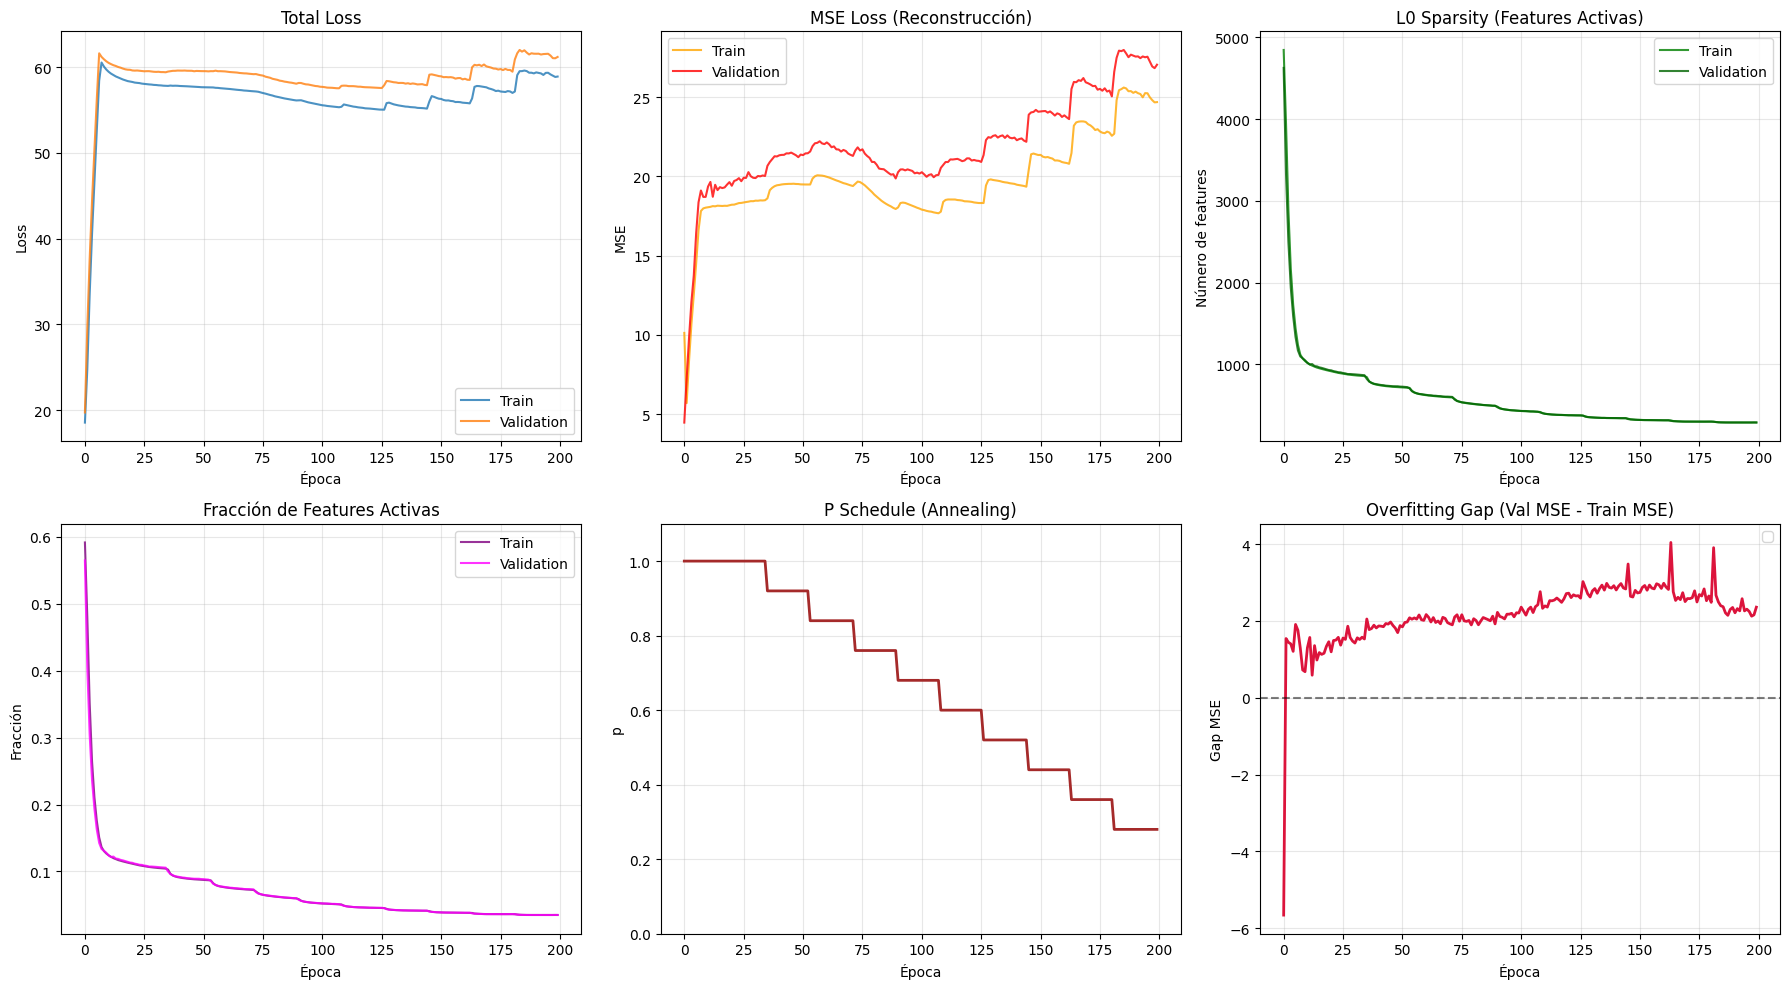


 ✓ Gráficas guardadas exitosamente


In [12]:
# Gráficas de pérdidas (Train vs Validation) + P-annealing schedule
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Total loss
axes[0, 0].plot(history['train_total_loss'], label='Train', alpha=0.8)
axes[0, 0].plot(history['val_total_loss'], label='Validation', alpha=0.8)
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MSE loss
axes[0, 1].plot(history['train_mse_loss'], label='Train', color='orange', alpha=0.8)
axes[0, 1].plot(history['val_mse_loss'], label='Validation', color='red', alpha=0.8)
if CONFIG['early_stopping'] and best_epoch > 0:
    axes[0, 1].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best (época {best_epoch})')
axes[0, 1].set_title('MSE Loss (Reconstrucción)')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('MSE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# L0 sparsity
axes[0, 2].plot(history['train_l0_sparsity'], label='Train', color='green', alpha=0.8)
axes[0, 2].plot(history['val_l0_sparsity'], label='Validation', color='darkgreen', alpha=0.8)
axes[0, 2].set_title('L0 Sparsity (Features Activas)')
axes[0, 2].set_xlabel('Época')
axes[0, 2].set_ylabel('Número de features')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Fraction active
axes[1, 0].plot(history['train_fraction_active'], label='Train', color='purple', alpha=0.8)
axes[1, 0].plot(history['val_fraction_active'], label='Validation', color='magenta', alpha=0.8)
axes[1, 0].set_title('Fracción de Features Activas')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Fracción')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# P schedule (annealing)
axes[1, 1].plot(history['p_history'], color='brown', linewidth=2, label='p')
axes[1, 1].set_title('P Schedule (Annealing)')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('p')
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].grid(True, alpha=0.3)

# Train vs Val MSE Gap
mse_gap = [v - t for v, t in zip(history['val_mse_loss'], history['train_mse_loss'])]
axes[1, 2].plot(mse_gap, color='crimson', linewidth=2)
axes[1, 2].axhline(0, color='black', linestyle='--', alpha=0.5)
if CONFIG['early_stopping'] and best_epoch > 0:
    axes[1, 2].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best')
axes[1, 2].set_title('Overfitting Gap (Val MSE - Train MSE)')
axes[1, 2].set_xlabel('Época')
axes[1, 2].set_ylabel('Gap MSE')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CONFIG['plots_dir'] / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n' + '='*50)
print(' ✓ Gráficas guardadas exitosamente')
print('='*50)

### 11. Resumen Final

In [13]:
# Resumen final completo
print('\n' + '='*70)
print(' RESUMEN FINAL DEL ENTRENAMIENTO')
print('='*70)

# Arquitectura
arch_summary = pd.DataFrame({
    'Componente': ['Input', 'Hidden', 'Parámetros'],
    'Valor': [
        f"{CONFIG['input_dim']}",
        f"{CONFIG['hidden_dim']} ({CONFIG['hidden_dim']/CONFIG['input_dim']:.1f}x)",
        f"{num_params:,}"
    ]
})
print('\nArquitectura:')
print(arch_summary.to_string(index=False))

# Datos
data_summary = pd.DataFrame({
    'Conjunto': ['Train', 'Validation', 'Total'],
    'Muestras': [
        f"{len(train_dataset):,}",
        f"{len(val_dataset):,}",
        f"{len(full_dataset):,}"
    ]
})
print('\nDatos:')
print(data_summary.to_string(index=False))

# Métricas finales
final_summary = pd.DataFrame({
    'Métrica': ['Train Loss', 'Val Loss', 'Train MSE', 'Val MSE', 'Train L0', 'Val L0'],
    'Valor': [
        f"{history['train_total_loss'][-1]:.4f}",
        f"{history['val_total_loss'][-1]:.4f}",
        f"{history['train_mse_loss'][-1]:.4f}",
        f"{history['val_mse_loss'][-1]:.4f}",
        f"{history['train_l0_sparsity'][-1]:.1f}",
        f"{history['val_l0_sparsity'][-1]:.1f}"
    ]
})
print('\nMétricas Finales:')
print(final_summary.to_string(index=False))

# Archivos
files_summary = pd.DataFrame({
    'Tipo': ['Modelo', 'Gráficas'],
    'Ubicación': [
        str(checkpoint_path),
        str(CONFIG['plots_dir'] / 'training_curves.png')
    ]
})
print('\nArchivos Guardados:')
print(files_summary.to_string(index=False))

print('\n' + '='*70)
print(' ✓ ENTRENAMIENTO COMPLETADO EXITOSAMENTE')
print('='*70)


 RESUMEN FINAL DEL ENTRENAMIENTO

Arquitectura:
Componente        Valor
     Input          512
    Hidden 8192 (16.0x)
Parámetros    8,397,312

Datos:
  Conjunto Muestras
     Train  590,000
Validation  147,500
     Total  737,500

Métricas Finales:
   Métrica   Valor
Train Loss 58.8964
  Val Loss 61.1813
 Train MSE 24.6830
   Val MSE 27.0423
  Train L0   286.6
    Val L0   286.3

Archivos Guardados:
    Tipo                                                                                                                                             Ubicación
  Modelo                                                                                               saved_model\sae_standard_p-annealing_l6_12500g_final.pt
Gráficas c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_p-annealing_standard\12500games\ex4\plots\training_curves.png

 ✓ ENTRENAMIENTO COMPLETADO EXITOSAMENTE


### 12. Generar PDF con Quarto

Una vez ejecutado todo el notebook, ejecutar el siguiente comando en la terminal para generar el PDF con Quarto:

In [14]:
import subprocess

# Obtener directorio del experimento y nombre del PDF
exp_dir = get_experiment_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)

pdf_name = get_report_name(
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    'training',
    extras_id=extras_id
)

notebook_name = 'train_sae_standard_pannealing.ipynb'
output_path = exp_dir / pdf_name

print(f' Generando PDF con Quarto...')
print(f' Archivo de salida: {output_path}')

# Quarto no acepta rutas en --output, solo nombre de archivo
# Se usa --output-dir para el directorio y --output solo para el nombre
result = subprocess.run(
    f'quarto render {notebook_name} --to pdf --output-dir "{exp_dir}" --output {pdf_name}',
    shell=True,
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(f' PDF generado exitosamente: {output_path}')
else:
    print(f' Error al generar PDF:')
    print(result.stderr)

 Generando PDF con Quarto...
 Archivo de salida: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_p-annealing_standard\12500games\ex4\sae_standard_p-annealing_l6_12500g_ex4_training.pdf
 PDF generado exitosamente: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_p-annealing_standard\12500games\ex4\sae_standard_p-annealing_l6_12500g_ex4_training.pdf
